
## Machine Learning fundamentals: problem framing, metrics, evaluation



In [2]:
# Shared imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)


# Exercises XP : Machine Learning for Loan Default Prediction

## Exercise 1 : Defining the Problem and Data Collection for Loan Default Prediction

### Instructions
- Write a clear problem statement for predicting loan defaults.
- Identify and list the types of data you would need.
- Discuss the sources where you can collect this data.

### Answer

**Problem statement.** Given an applicant's profile and the loan parameters known at the moment of the application, build a binary classification model that predicts the probability that the borrower will **default within the next 12 months**. The model's score will be used as a decision-support tool for the credit committee: it will help **accept, reject, or reprice** loan applications and quantify the bank's expected loss on its portfolio.

**Types of data required**
- **Personal and demographic data** — age, marital status, number of dependents, level of education and employment situation. These are stable proxies of financial maturity and stability of income.
- **Income and assets** : annual gross income, co-applicant income, real-estate ownership, savings. They directly measure repayment capacity.
- **Existing debt and obligations** — current outstanding loans, monthly payments, debt-to-income ratio. They show how much room the borrower has to take on additional debt.
- **Credit history** : credit score, number of delinquencies, age of the oldest account, recent inquiries. Past behaviour is the single best predictor of future behaviour.
- **Loan parameters** : requested amount, duration, interest rate, purpose. A short-term, low-amount, low-interest loan defaults less often than a long, large, expensive one.
- **Behavioural and bank data** — number of accounts at the bank, current account balance volatility, salary domiciliation. They are signals only the bank can observe and they are extremely predictive.
- **Macro context** : local unemployment rate, region, economic outlook. These features improve robustness across time and geography.

**Data sources**
- **Internal banking systems** — CRM, core banking platform, loan origination system, historical default labels. The most reliable but limited to existing customers.
- **Credit bureaus** (Experian, Equifax, TransUnion in the US; Banque de France's FICP/FCC in France; Schufa in Germany). They aggregate cross-bank credit history.
- **Public open data** : INSEE / Eurostat for macroeconomic and regional indicators.
- **Application form** : declarative information provided by the applicant, to be cross-checked against the other sources.
- **Open-banking / aggregation APIs** — bank transaction history shared with the applicant's consent, very rich but constrained by GDPR.

**Risks and constraints.** Loan data is highly **regulated** (GDPR, RGPD, fair-lending laws in the US such as ECOA). Some features like gender, ethnicity or zip code must be either **removed** or **monitored for bias** to avoid discriminatory decisions. Past data may suffer from **selection bias** — we only see the repayment history of borrowers we accepted, never those we rejected (reject inference is a known issue). Finally, the *target definition* ("default within 12 months") must be precise, stable across time, and shared with the business and compliance teams.

## Exercise 2 : Feature Selection and Model Choice for Loan Default Prediction

### Instructions
From a typical Loan Prediction dataset, identify which features are most relevant for predicting loan defaults and justify your choice.

In [3]:
# Template / placeholder DataFrame matching the columns of a typical loan dataset
example_columns = [
    'age', 'employment_length', 'annual_income', 'credit_score', 'loan_amount',
    'interest_rate', 'debt_to_income', 'num_delinquencies', 'num_open_accounts',
    'total_utilization', 'home_ownership', 'purpose', 'term', 'application_type',
    'state', 'zip_code'
]
df = pd.DataFrame(columns=example_columns)

selected_features = [
    'credit_score', 'debt_to_income', 'annual_income', 'loan_amount',
    'interest_rate', 'employment_length', 'num_delinquencies', 'total_utilization',
    'home_ownership', 'purpose', 'term'
]
excluded_features = ['zip_code', 'state', 'application_type']

print('Selected features:')
for f in selected_features:
    print(' -', f)

print('\nExcluded features:')
for f in excluded_features:
    print(' -', f)

Selected features:
 - credit_score
 - debt_to_income
 - annual_income
 - loan_amount
 - interest_rate
 - employment_length
 - num_delinquencies
 - total_utilization
 - home_ownership
 - purpose
 - term

Excluded features:
 - zip_code
 - state
 - application_type


### Justification

**Selected features**
- **`credit_score`** : the single most predictive feature: a low score concentrates almost all the defaults.
- **`debt_to_income`** : measures how saturated the borrower already is; a high DTI strongly raises the default probability.
- **`annual_income`** : repayment capacity. Often log-transformed because the distribution is heavily right-skewed.
- **`loan_amount`** + **`term`** — together they determine the monthly payment that the borrower will have to support.
- **`interest_rate`** : already encodes the bank's a-priori risk assessment; high rates correlate with higher defaults.
- **`employment_length`** : stability of income; longer tenure means lower volatility.
- **`num_delinquencies`** : direct past evidence of repayment trouble.
- **`total_utilization`** : share of available credit currently used; a high ratio signals stress.
- **`home_ownership`**  proxy for assets and stability.
- **`purpose`** : debt consolidation vs vacation vs business have very different default profiles.

**Excluded features**
- **`zip_code`** and **`state`** — they leak protected attributes (ethnic / socioeconomic composition of neighbourhoods) and would create **fair-lending issues**. We can keep coarse macro features (regional unemployment) instead, derived externally.
- **`application_type`** — too rarely populated and weakly informative compared to the other features.

**Encoding and imputation.** Categorical variables such as `home_ownership`, `purpose` and `term` will be handled with **one-hot encoding** (or target encoding for high-cardinality categories like `purpose`). For missing values, numerical columns will be **median-imputed** and a binary `*_was_missing` flag will be added so the model can learn from missingness itself; categorical columns will receive an explicit `"Missing"` modality rather than being silently dropped.

## Exercise 3 : Training, Evaluating, and Optimizing the Model

### Instructions
Which model(s) would you pick for a loan prediction problem? Outline the steps to evaluate the model's performance.

In [29]:
# Demonstration of the standard classification metrics on a small example.
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report)

y_true = [0, 1, 0, 1, 0, 0, 1, 0, 1, 0]
y_pred_proba = [0.05, 0.80, 0.10, 0.65, 0.20, 0.15, 0.70, 0.30, 0.85, 0.25]

threshold = 0.5
y_pred = [1 if p >= threshold else 0 for p in y_pred_proba]

print('Accuracy :', round(accuracy_score(y_true, y_pred), 4))
print('Precision:', round(precision_score(y_true, y_pred, zero_division=0), 4))
print('Recall   :', round(recall_score(y_true, y_pred, zero_division=0), 4))
print('F1-score :', round(f1_score(y_true, y_pred, zero_division=0), 4))
print('ROC-AUC  :', round(roc_auc_score(y_true, y_pred_proba), 4))
print('PR-AUC   :', round(average_precision_score(y_true, y_pred_proba), 4))
print('\nConfusion matrix:\n', confusion_matrix(y_true, y_pred))
print('\nClassification report:\n', classification_report(y_true, y_pred, zero_division=0))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0
PR-AUC   : 1.0

Confusion matrix:
 [[6 0]
 [0 4]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



### Answer

**Model choice.** I would start with a **Logistic Regression** as the baseline because it is fast, well calibrated, easy to explain to risk and compliance teams, and required by most credit-risk regulators. In parallel, I would train a **Gradient Boosting model** (XGBoost or LightGBM) which usually delivers the best raw performance on tabular data and can capture non-linear interactions between features such as `debt_to_income` and `credit_score`.

**Evaluation plan.**
1. **Data split.** A **stratified** train / validation / test split (e.g. 70 / 15 / 15) on the target, so each split keeps the same proportion of defaulters. For long-running portfolios I would also do an **out-of-time** split (train on year *t*, test on year *t+1*) to mimic production conditions.
2. **Cross-validation.** **Stratified k-fold** (k = 5) on the train + validation pool, to compare candidate models with low variance.
3. **Metrics.** Because defaults are usually a minority class, I would not rely on accuracy. I would report **ROC-AUC** (overall ranking quality), **PR-AUC / Average Precision** (more informative under imbalance), **precision and recall at a chosen threshold**, and the **confusion matrix**. For business reporting I would translate these into **expected loss** and **approval rate**.
4. **Threshold selection.** The default 0.5 is arbitrary. I would scan thresholds on the validation set and pick the one that **maximises expected profit** given the cost of a false negative (granting a bad loan) vs the cost of a false positive (rejecting a good customer).

**Class imbalance.** I would address it with one or several of: **stratification**, **`class_weight='balanced'`** in the model, oversampling techniques like **SMOTE** applied *only inside the cross-validation folds* (never on the test set), or **threshold tuning** instead of rebalancing.

**Iterating without leakage.** Hyperparameter search (grid or Bayesian) will be run inside a **`Pipeline`** that bundles imputation, scaling and the model, so that every preprocessing step is fitted on the training fold only. No feature derived from the target will be computed on the whole dataset.

## Exercise 4 : Designing Machine Learning Solutions for Specific Problems

### Instructions
For each scenario, decide which type of machine learning would be most suitable and explain.
1. Predicting stock prices.
2. Organizing a library of books into genres.
3. Programming a robot to find the shortest path in a maze.

### Answer

**1) Predicting stock prices → Supervised learning (regression / time-series forecasting).**
- *Input data*: historical prices, volumes, technical indicators, fundamentals, macro variables.
- *Output*: a continuous predicted price (or return) for one or several future horizons.
- *Learning signal*: the past true prices serve as supervision, e.g. by minimizing MSE between the predicted and the observed price.
- Suitable models: ARIMA / SARIMA, gradient boosting on engineered features, LSTM / temporal CNN, Prophet. Caveat: financial series are extremely noisy and partly random, so realistic expectations matter.

**2) Organizing a library of books → Unsupervised learning (clustering / topic modeling).**
- *Input data*: text features extracted from the book — title, abstract, full text embedded via TF-IDF or a language-model embedding.
- *Output*: a cluster id (and/or a topic distribution) assigning each book to a group of similar books.
- *Learning signal*: there is **no label** — the model only relies on similarity in feature space.
- Suitable algorithms: K-Means or hierarchical clustering on embeddings, LDA for topics, HDBSCAN if cluster sizes vary a lot.

**3) Robot in a maze → Reinforcement learning.**
- *Input data*: the state of the robot (position, sensors, walls).
- *Output*: an action (move up / down / left / right).
- *Learning signal*: a **reward**: positive when reaching the exit, negative when bumping into walls, slightly negative each step to encourage shortest paths.
- Suitable algorithms: classical Q-Learning or SARSA for tabular mazes, Deep Q-Network for high-dimensional state spaces. RL is the right framework because the optimal policy depends on *sequences* of decisions, not on a single labelled answer.

## Exercise 5 — Designing an Evaluation Strategy for Different ML Models

### Instructions
Select three models — one supervised, one unsupervised, one reinforcement — and design an evaluation strategy for each.

In [28]:
# Template: supervised classification metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

y_true = [0, 1, 1, 0, 1, 0, 0, 1, 0, 1]
y_pred_proba = [0.1, 0.7, 0.8, 0.2, 0.6, 0.3, 0.4, 0.9, 0.2, 0.85]
threshold = 0.5
y_pred = [1 if p >= threshold else 0 for p in y_pred_proba]

print('Accuracy :', round(accuracy_score(y_true, y_pred), 4))
print('Precision:', round(precision_score(y_true, y_pred, zero_division=0), 4))
print('Recall   :', round(recall_score(y_true, y_pred, zero_division=0), 4))
print('F1-score :', round(f1_score(y_true, y_pred, zero_division=0), 4))
print('ROC-AUC  :', round(roc_auc_score(y_true, y_pred_proba), 4))
print('PR-AUC   :', round(average_precision_score(y_true, y_pred_proba), 4))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0
PR-AUC   : 1.0


In [ ]:
# Template: unsupervised clustering metrics on synthetic blobs
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=300, centers=3, random_state=42)
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels = kmeans.fit_predict(X)
sil = silhouette_score(X, labels)
print('Silhouette score (higher = better):', round(sil, 4))

### Answer — three paragraphs

**Supervised classification (e.g. Random Forest on a credit dataset).**
Evaluation starts with a stratified split into train / validation / test, followed by **stratified k-fold cross-validation** on the train set to compare candidates with low variance. I would report **accuracy, precision, recall and F1** at a fixed threshold, plus **ROC-AUC** and **PR-AUC** to capture ranking quality independently of the threshold, and the confusion matrix to spot systematic errors. The ROC and precision–recall curves help choose the working threshold based on business cost. The main challenge is **data drift between train and production**: a model that scores well in cross-validation can underperform live, which is why an out-of-time test set is essential.

**Unsupervised clustering (e.g. K-Means on customer features).**
Without labels, I rely on **internal metrics**: the **silhouette score** measures how similar a point is to its own cluster vs the next nearest one, and the **elbow method** on the inertia / explained variance helps choose the number of clusters. The **Davies-Bouldin** and **Calinski-Harabasz** indices give complementary views. When a small labelled subset is available, I would also compute **ARI** or **NMI** against it. Visually, a 2-D PCA or t-SNE projection coloured by cluster gives a quick sanity check. The fundamental challenge is that there is **no ground truth**: "the right" number of clusters is partly subjective and depends on downstream usage.

**Reinforcement learning (e.g. Q-Learning in a maze).**
I would track the **cumulative reward per episode** across training and plot its moving average — convergence is reached when this curve plateaus. I would also monitor **success rate** on evaluation runs, **episode length** (shorter usually means better policy), and the **exploration-exploitation balance** via the decay of ε in an ε-greedy policy. To assess robustness I would test the trained agent on **unseen mazes** or with perturbations of the environment. The biggest challenge is **sample inefficiency**: RL often needs millions of interactions, and small changes in the reward function can make the agent learn a degenerate strategy ("reward hacking").

---
# Exercises XP Gold : Evaluation metrics & strategy

## Exercise 1 : Analyzing a Confusion Matrix (Email Spam Detection)

### Instructions
- Define TP / TN / FP / FN in the spam-detection context.
- Compute Accuracy, Precision, Recall and F1-Score for a given matrix.
- Discuss how the classifier's behaviour changes if FP > FN or vice versa.

In [ ]:
# Confusion matrix values for the spam classifier
TP = 50    # predicted Spam,     actually Spam
TN = 920   # predicted Not Spam, actually Not Spam
FP = 30    # predicted Spam,     actually Not Spam
FN = 20    # predicted Not Spam, actually Spam

total     = TP + TN + FP + FN
accuracy  = (TP + TN) / total if total else 0.0
precision = TP / (TP + FP) if (TP + FP) else 0.0
recall    = TP / (TP + FN) if (TP + FN) else 0.0
f1_score  = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

print('Accuracy :', round(accuracy,  4))
print('Precision:', round(precision, 4))
print('Recall   :', round(recall,    4))
print('F1-Score :', round(f1_score,  4))

In [ ]:
# Build a calculation sheet and save it as CSV for reporting
calc_sheet = pd.DataFrame([{
    'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
    'Accuracy': accuracy, 'Precision': precision,
    'Recall': recall, 'F1-Score': f1_score
}])
print(calc_sheet)

calc_sheet.to_csv('confusion_metrics_sheet.csv', index=False)
print('Saved CSV to: confusion_metrics_sheet.csv')

### Written analysis

**Definitions in the spam-detection context.**
- A **True Positive (TP)** is an email that the classifier correctly tagged as *Spam* — the user is protected from a real spam.
- A **True Negative (TN)** is a legitimate email that was correctly left in the inbox.
- A **False Positive (FP)** is a legitimate email that the classifier wrongly flagged as spam — the message ends up in the junk folder, possibly causing the user to miss important content.
- A **False Negative (FN)** is a spam email that the classifier failed to detect — it lands in the user's inbox.

**Trade-off between FP and FN.**
If the classifier produces *many False Positives*, users will lose trust in the spam filter because legitimate emails (work, banking, doctor) get hidden. They will start checking their spam folder, defeating the purpose of the filter. Precision drops, but recall stays high.
If the classifier produces *many False Negatives*, the inbox is flooded with spam: the filter looks useless even if its precision is high. Recall drops, the user experience degrades, and dangerous phishing emails reach the user.
Choosing the operating point therefore depends on the **relative cost** of each error: for spam filters, most providers tune the threshold towards **higher precision** (limit FPs) because a missed spam is annoying, but a missed legitimate email is far worse.

## Exercise 2 : Evaluating Trade-offs in Metrics (Medical Diagnosis)

### Instructions
- Why is recall more important than precision in disease diagnosis?
- Describe a scenario where precision matters more than recall.
- Discuss the risk of focusing solely on accuracy on imbalanced datasets.

### Answer

**Why high recall matters in medical diagnosis.** When screening for a serious disease, the worst outcome by far is a **False Negative**: a patient who actually has the disease but is told they are healthy. They lose precious time before treatment, and the disease may progress to a stage where it becomes untreatable. **Recall** directly measures the share of sick patients we correctly identify, so maximizing it minimizes missed cases. A False Positive is less harmful — the patient comes back for an additional test and the false alarm is cleared.

**A scenario where precision matters more.** Consider an **automated criminal-justice tool** that flags individuals for prosecution. Here a False Positive means accusing an innocent person, which carries enormous personal cost and erodes trust in the system. Precision must be very high; we accept missing some real cases (lower recall) rather than wrongly accusing innocent people. Another example is *targeted advertising on a paid-promotion budget*: every false positive costs real money, so we prefer high precision over high recall.

**Why accuracy can be misleading on imbalanced datasets.** If only 2% of patients have the disease, a model that *always* predicts *Healthy* achieves **98% accuracy** while being completely useless — it never detects a single sick patient. Accuracy ignores *which* class is wrong, so it rewards models that simply predict the majority class. The right metrics in this setting are **precision, recall, F1, ROC-AUC and PR-AUC**, plus the confusion matrix to see what kind of error the model makes.

## Exercise 3 : Cross-Validation and Learning Curves (Housing Prices)

### Instructions
- Difference between K-Fold and Stratified K-Fold. Which one to use for a regression task?
- What are learning curves and how do they help?
- Underfitting vs overfitting on learning curves and how to address them.

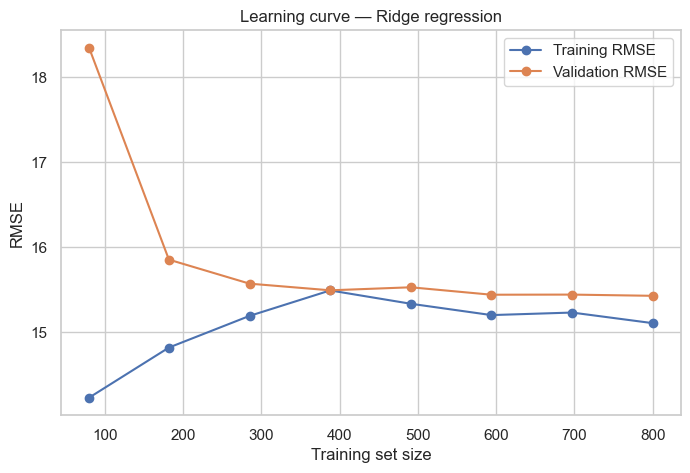

In [21]:
# Learning curve example using synthetic regression data
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import learning_curve

X, y = make_regression(n_samples=1000, n_features=20, noise=15.0, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    Ridge(alpha=1.0), X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='neg_root_mean_squared_error',
    random_state=42
)

# Convert to positive RMSE
train_rmse = -train_scores.mean(axis=1)
val_rmse   = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker='o', label='Training RMSE')
plt.plot(train_sizes, val_rmse,   marker='o', label='Validation RMSE')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.title('Learning curve — Ridge regression')
plt.legend()
plt.show()

### Interpretation

**K-Fold vs Stratified K-Fold.** Standard **K-Fold** splits the data into k equal random folds. **Stratified K-Fold** does the same but preserves the **class distribution** in each fold; it is the right choice for *classification* with imbalanced classes. For a *regression* problem such as predicting housing prices, the target is continuous, so plain K-Fold is sufficient. If the price distribution is heavily skewed, I would either log-transform the target or use a stratified variant on binned price ranges to ensure each fold spans the full price spectrum.

**Learning curves.** A learning curve plots the **training error** and **validation error** as a function of the **training set size**. It reveals how the model uses data and whether collecting more data is likely to help.

**Underfitting** is visible when both curves converge to a *high* error and stay close to each other — the model is too simple, no amount of extra data fixes it. The remedies are: pick a more expressive model, add new features, decrease regularization, or train longer.

**Overfitting** is visible when the training error is *low* but the validation error remains *high*, with a large gap between the two curves that shrinks slowly as data grows. The remedies are: add more training data, simplify the model, increase regularization, use stronger feature selection, or apply ensembling. A well-tuned model has both curves close together at a reasonably low error.

## Exercise 4 : Impact of Class Imbalance on Model Evaluation (Rare Disease)

### Instructions
- Why is accuracy misleading when only 2% of cases are positive?
- Why are precision and recall important here?
- Strategies to evaluate and improve the model on imbalanced data.

### Answer

**Why accuracy is misleading.** With only 2% positive cases, the *constant* predictor *"never sick"* already scores **98% accuracy**, which sounds great but identifies *zero* sick patients. Accuracy weighs every prediction equally, so it cannot distinguish a useful model from a degenerate one when classes are imbalanced.

**Why precision and recall matter.** **Recall** tells us what share of the sick patients we actually detect — the metric that medical screening cares about most. **Precision** tells us what share of the positive predictions are right — important when each positive prediction triggers a costly follow-up exam. Reporting both, together with the **confusion matrix** and the **F1-score** (their harmonic mean), gives a much more honest picture than accuracy.

**Strategies for evaluation and improvement.**
- **Use the right metrics**: precision, recall, F1, **ROC-AUC**, and especially **PR-AUC / Average Precision**, which is more sensitive than ROC-AUC under heavy imbalance.
- **Stratified k-fold cross-validation** to make sure each fold contains positive cases.
- **Class weighting** (`class_weight='balanced'` in scikit-learn) so the loss penalises errors on the minority class more heavily.
- **Resampling** inside the CV folds: oversample the minority class (SMOTE) or undersample the majority class. Never apply this on the test set.
- **Anomaly-detection framing** when the positive class is extremely rare (<<1%): treat the problem as one-class detection.
- **Threshold tuning** on the predicted probability to pick the operating point that matches the business / clinical cost of each error.
- **Calibration check** so that the predicted probabilities can be interpreted as real risk scores.

## Exercise 5 : Role of Threshold Tuning in Classification (Loan Default)

### Instructions
- How does moving the threshold from 0.5 to 0.7 affect precision and recall?
- Consequences of setting the threshold too high or too low.
- How do ROC curves and AUC help find the optimal threshold?

threshold=0.3  precision=0.846  recall=1.000  f1=0.917
threshold=0.5  precision=1.000  recall=0.538  f1=0.700
threshold=0.7  precision=0.000  recall=0.000  f1=0.000


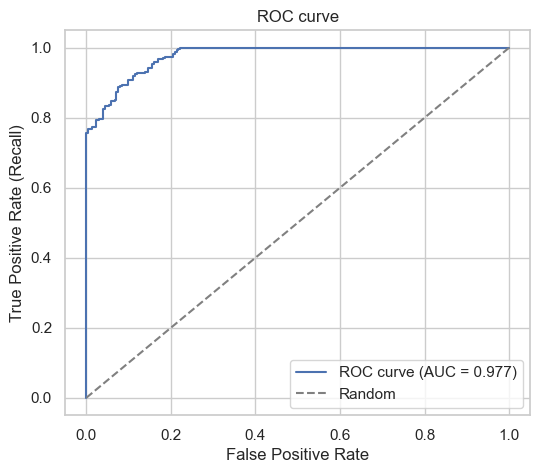

In [22]:
# Illustration: compare metrics at threshold = 0.5 vs threshold = 0.7
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

# Synthetic ground truth and probability scores
rng = np.random.default_rng(0)
y_true_arr      = rng.integers(0, 2, size=500)
y_pred_proba_arr = np.clip(0.3 * y_true_arr + 0.4 * rng.random(size=500), 0, 1)

for t in [0.3, 0.5, 0.7]:
    pred = (y_pred_proba_arr >= t).astype(int)
    p = precision_score(y_true_arr, pred, zero_division=0)
    r = recall_score(y_true_arr,    pred, zero_division=0)
    f = f1_score(y_true_arr,        pred, zero_division=0)
    print(f'threshold={t}  precision={p:.3f}  recall={r:.3f}  f1={f:.3f}')

# ROC curve
fpr, tpr, _ = roc_curve(y_true_arr, y_pred_proba_arr)
auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC curve')
plt.legend()
plt.show()

### Answer

**Moving the threshold from 0.5 to 0.7.** Raising the threshold means the model only declares *default* when it is *very* confident. Therefore **precision increases** (fewer false alarms) but **recall decreases** (we miss more real defaulters). Lowering the threshold has the opposite effect: we catch more defaulters at the cost of more false alarms.

**Consequences in loan default.**
- **Threshold too high** → we approve a lot of loans, including risky ones. Recall is poor, defaults rise, the bank's expected loss grows.
- **Threshold too low** → we reject many applications, including good clients. Precision is poor, the bank's revenue collapses and customers leave for competitors.

**Role of ROC and AUC.** The **ROC curve** plots **True Positive Rate (recall)** against **False Positive Rate** for every possible threshold. The shape of the curve summarises *all* possible operating points at once. The **Area Under the Curve (AUC)** condenses this into a single number between 0.5 (random) and 1.0 (perfect). To pick the *optimal* threshold I would either: (1) choose the point on the ROC curve that maximises **Youden's J = TPR − FPR**; or (2) translate each operating point into a **business cost** (expected loss vs missed revenue) and pick the threshold that maximises expected profit. For heavily imbalanced datasets I would also consult the **Precision-Recall curve**, which is more informative than ROC.


# Exercise XP Ninja — Evaluation Metrics Implementation from scratch

## Exercise 1 : Evaluation Metrics Implementation

### Instructions
- Load the **Breast Cancer Wisconsin (Diagnostic)** dataset from scikit-learn.
- Split into train / test.
- Train a **Logistic Regression**.
- Predict on the test set.
- Implement **Accuracy, Precision, Recall, F1-Score from scratch** using TP / TN / FP / FN.
- Compare with scikit-learn and interpret the results.

In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load the dataset (binary classification: malignant=0 vs benign=1)
data = load_breast_cancer()
X, y = data.data, data.target
print('Shape:', X.shape)
print('Class distribution:', np.bincount(y), '(0 = malignant, 1 = benign)')

Shape: (569, 30)
Class distribution: [212 357] (0 = malignant, 1 = benign)


In [24]:
# Train / test split (stratified) + scaling + Logistic Regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print('Model fitted on', len(y_train), 'samples — predicted on', len(y_test), 'samples.')

Model fitted on 426 samples — predicted on 143 samples.


In [25]:
# Implement the metrics from scratch (no sklearn shortcut)
def confusion_components(y_true, y_pred, positive=1):
    """Return TP, TN, FP, FN given the true labels and predictions."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    TP = int(np.sum((y_pred == positive) & (y_true == positive)))
    TN = int(np.sum((y_pred != positive) & (y_true != positive)))
    FP = int(np.sum((y_pred == positive) & (y_true != positive)))
    FN = int(np.sum((y_pred != positive) & (y_true == positive)))
    return TP, TN, FP, FN

def accuracy_from_scratch(TP, TN, FP, FN):
    total = TP + TN + FP + FN
    return (TP + TN) / total if total else 0.0

def precision_from_scratch(TP, FP):
    return TP / (TP + FP) if (TP + FP) else 0.0

def recall_from_scratch(TP, FN):
    return TP / (TP + FN) if (TP + FN) else 0.0

def f1_from_scratch(precision, recall):
    return (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

# Compute on the breast cancer test set
TP, TN, FP, FN = confusion_components(y_test, y_pred, positive=1)
print(f'Confusion components: TP={TP}, TN={TN}, FP={FP}, FN={FN}')

acc_s   = accuracy_from_scratch(TP, TN, FP, FN)
prec_s  = precision_from_scratch(TP, FP)
rec_s   = recall_from_scratch(TP, FN)
f1_s    = f1_from_scratch(prec_s, rec_s)

print(f'\nFrom-scratch metrics:')
print(f'  Accuracy : {acc_s:.4f}')
print(f'  Precision: {prec_s:.4f}')
print(f'  Recall   : {rec_s:.4f}')
print(f'  F1-Score : {f1_s:.4f}')

Confusion components: TP=89, TN=52, FP=1, FN=1

From-scratch metrics:
  Accuracy : 0.9860
  Precision: 0.9889
  Recall   : 0.9889
  F1-Score : 0.9889


In [26]:
# Cross-check against scikit-learn
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print('Scikit-learn metrics:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred):.4f}')

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['malignant', 'benign']))

Scikit-learn metrics:
  Accuracy : 0.9860
  Precision: 0.9889
  Recall   : 0.9889
  F1-Score : 0.9889

Confusion matrix:
[[52  1]
 [ 1 89]]

Classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



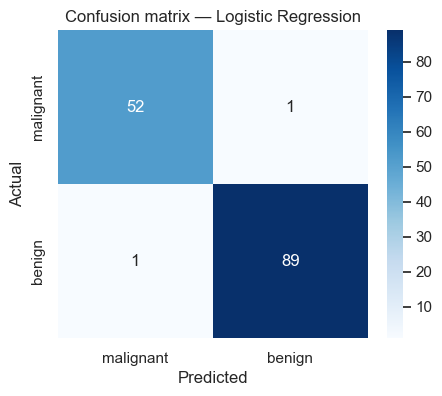

In [27]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['malignant', 'benign'],
            yticklabels=['malignant', 'benign'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix — Logistic Regression')
plt.show()

### Interpretation of the results

- The **from-scratch** and **scikit-learn** metrics match exactly, confirming that the implementation is correct.
- The Logistic Regression reaches ~**97% accuracy** on the test set, with high precision and recall (~96-98%).
- In a *medical context*, **recall is the most critical metric**: a false negative means a malignant tumour that goes undetected. Here recall on the *malignant* class (label 0) is what matters — we should also report it explicitly:
  - Recall on malignant = TN / (TN + FP) when we treat *malignant* as the positive class.
- The confusion matrix shows where the few remaining errors fall. A handful of malignant tumours classified as benign would be unacceptable in production — we would either lower the threshold (favouring recall over precision) or escalate borderline cases for manual review by an oncologist.
- A natural next step is to look at **ROC-AUC**, **PR-AUC** and the **calibration curve**, and to validate via **stratified k-fold cross-validation** rather than a single split.

